

**Electric Vehicle Analysis**


In [ ]:
!pip install pyspark


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
from pyspark.sql.functions import *
from pyspark.ml.feature import VectorAssembler, StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder.appName("HW4").getOrCreate()

In [ ]:
file_path = "/content/drive/MyDrive/Electric_Vehicle_Population_Data.csv"

EvDF =spark.read.options(mode='FAILFAST',
                              header = True,
                              multiLine=True,
                              inferSchema=True,
                              escape='"').csv(file_path)



display(EvDF)

DataFrame[VIN (1-10): string, County: string, City: string, State: string, Postal Code: int, Model Year: int, Make: string, Model: string, Electric Vehicle Type: string, Clean Alternative Fuel Vehicle (CAFV) Eligibility: string, Electric Range: int, Base MSRP: int, Legislative District: int, DOL Vehicle ID: int, Vehicle Location: string, Electric Utility: string, 2020 Census Tract: bigint]

In [ ]:
EvDF.describe().show()

+-------+----------+------+--------+------+-----------------+------------------+--------------------+------------------+---------------------+-------------------------------------------------+-----------------+-----------------+--------------------+-------------------+--------------------+--------------------+--------------------+
|summary|VIN (1-10)|County|    City| State|      Postal Code|        Model Year|                Make|             Model|Electric Vehicle Type|Clean Alternative Fuel Vehicle (CAFV) Eligibility|   Electric Range|        Base MSRP|Legislative District|     DOL Vehicle ID|    Vehicle Location|    Electric Utility|   2020 Census Tract|
+-------+----------+------+--------+------+-----------------+------------------+--------------------+------------------+---------------------+-------------------------------------------------+-----------------+-----------------+--------------------+-------------------+--------------------+--------------------+--------------------+
|

In [ ]:
null_counts = EvDF.select([sum(col(c).isNull().cast('int')).alias(c) for c in EvDF.columns])
null_counts.show()

+----------+------+----+-----+-----------+----------+----+-----+---------------------+-------------------------------------------------+--------------+---------+--------------------+--------------+----------------+----------------+-----------------+
|VIN (1-10)|County|City|State|Postal Code|Model Year|Make|Model|Electric Vehicle Type|Clean Alternative Fuel Vehicle (CAFV) Eligibility|Electric Range|Base MSRP|Legislative District|DOL Vehicle ID|Vehicle Location|Electric Utility|2020 Census Tract|
+----------+------+----+-----+-----------+----------+----+-----+---------------------+-------------------------------------------------+--------------+---------+--------------------+--------------+----------------+----------------+-----------------+
|         0|    11|  11|    0|         11|         0|   0|    0|                    0|                                                0|             4|        4|                 664|             0|              89|              11|               11|


In [ ]:
EvDF.printSchema()

root
 |-- VIN (1-10): string (nullable = true)
 |-- County: string (nullable = true)
 |-- City: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Postal Code: integer (nullable = true)
 |-- Model Year: integer (nullable = true)
 |-- Make: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- Electric Vehicle Type: string (nullable = true)
 |-- Clean Alternative Fuel Vehicle (CAFV) Eligibility: string (nullable = true)
 |-- Electric Range: integer (nullable = true)
 |-- Base MSRP: integer (nullable = true)
 |-- Legislative District: integer (nullable = true)
 |-- DOL Vehicle ID: integer (nullable = true)
 |-- Vehicle Location: string (nullable = true)
 |-- Electric Utility: string (nullable = true)
 |-- 2020 Census Tract: long (nullable = true)



Data Preparation

In [ ]:
from pyspark.sql import functions as F

Evnew=EvDF

#Standardizing text columns
string_cols = ["County", "City", "State", "Make", "Model",
               "Electric Vehicle Type",
               "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
               "Electric Utility"]

for col_name in string_cols:
    Evnew = Evnew.withColumn(col_name, F.initcap(F.trim(F.col(col_name))))

In [ ]:
# Data type casting
Evnew = Evnew.withColumn("Postal Code", F.col("Postal Code").cast("string"))
Evnew= Evnew.withColumn("2020 Census Tract", F.col("2020 Census Tract").cast("string"))
Evnew=Evnew.withColumn("Model Year", F.col("Model Year").cast("string"))

In [ ]:
#Drop duplicate VIN's
Evnew = Evnew.dropDuplicates(["VIN (1-10)"])


In [ ]:
# Filtering EV from 2010 to 2026
Evnew = Evnew.filter((F.col("Model Year") >= 2010) & (F.col("Model Year") <= 2026))

Handling Null Values

Numeric Columns : `Base MSRP`, `Electric Range` - Filling Null Values by computing `median_msrp` , `median_range` grouping by each model and make.

In [ ]:
# Compute median MSRP per model
msrp_median = (
    Evnew.groupBy("Make", "Model")
      .agg(F.expr("percentile_approx(`Base MSRP`, 0.5)").alias("median_msrp"))
)

Evnew = Evnew.join(msrp_median, ["Make", "Model"], "left")

Evnew = Evnew.withColumn(
    "Base MSRP",
    F.when((F.col("Base MSRP") < 20000) | (F.col("Base MSRP") > 200000) | (F.col("Base MSRP").isNull()),
           F.col("median_msrp"))
     .otherwise(F.col("Base MSRP"))
)

Evnew = Evnew.drop("median_msrp")

In [ ]:
range_avg = (
    Evnew.groupBy("Make", "Model")
      .agg(F.avg("Electric Range").alias("avg_range"))
)

Evnew = Evnew.join(range_avg, ["Make", "Model"], "left")

Evnew = Evnew.withColumn(
    "Electric Range",
    F.when(F.col("Electric Range").isNull(), F.col("avg_range"))
     .otherwise(F.col("Electric Range"))
)

Evnew = Evnew.drop("avg_range")


In [ ]:
null_countnew = Evnew.select([sum(col(c).isNull().cast('int')).alias(c) for c in Evnew.columns])
null_countnew.show()

+----+-----+----------+------+----+-----+-----------+----------+---------------------+-------------------------------------------------+--------------+---------+--------------------+--------------+----------------+----------------+-----------------+
|Make|Model|VIN (1-10)|County|City|State|Postal Code|Model Year|Electric Vehicle Type|Clean Alternative Fuel Vehicle (CAFV) Eligibility|Electric Range|Base MSRP|Legislative District|DOL Vehicle ID|Vehicle Location|Electric Utility|2020 Census Tract|
+----+-----+----------+------+----+-----+-----------+----------+---------------------+-------------------------------------------------+--------------+---------+--------------------+--------------+----------------+----------------+-----------------+
|   0|    0|         0|     3|   3|    0|          3|         0|                    0|                                                0|             0|        0|                  11|             0|               4|               3|                3|


For Categorical columns replacing missing values by imputing mode


In [ ]:
def fill_with_mode(Evnew, colname):
    mode_value = (
        Evnew.groupBy(colname)
          .count()
          .orderBy(F.desc("count"))
          .first()[0]
    )
    return Evnew.fillna({colname: mode_value})

categorical_cols = ["County", "City", "Electric Utility","2020 Census Tract","Postal Code"]

for c in categorical_cols:
    Evnew = fill_with_mode(Evnew, c)


In [ ]:
# Dropping null values in Vehicle location and Legislative District
cols = ["Vehicle Location","Legislative District"]
Evnew = Evnew.na.drop(subset=cols)


In [ ]:
null_countnew = Evnew.select([sum(col(c).isNull().cast('int')).alias(c) for c in Evnew.columns])
null_countnew.show()

+----+-----+----------+------+----+-----+-----------+----------+---------------------+-------------------------------------------------+--------------+---------+--------------------+--------------+----------------+----------------+-----------------+
|Make|Model|VIN (1-10)|County|City|State|Postal Code|Model Year|Electric Vehicle Type|Clean Alternative Fuel Vehicle (CAFV) Eligibility|Electric Range|Base MSRP|Legislative District|DOL Vehicle ID|Vehicle Location|Electric Utility|2020 Census Tract|
+----+-----+----------+------+----+-----+-----------+----------+---------------------+-------------------------------------------------+--------------+---------+--------------------+--------------+----------------+----------------+-----------------+
|   0|    0|         0|     0|   0|    0|          0|         0|                    0|                                                0|             0|        0|                   0|             0|               0|               0|                0|


In [ ]:
Evnew.describe().show()

+-------+--------------------+------------------+----------+------+--------+-----+-----------------+------------------+---------------------+-------------------------------------------------+------------------+------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|summary|                Make|             Model|VIN (1-10)|County|    City|State|      Postal Code|        Model Year|Electric Vehicle Type|Clean Alternative Fuel Vehicle (CAFV) Eligibility|    Electric Range|         Base MSRP|Legislative District|      DOL Vehicle ID|    Vehicle Location|    Electric Utility|   2020 Census Tract|
+-------+--------------------+------------------+----------+------+--------+-----+-----------------+------------------+---------------------+-------------------------------------------------+------------------+------------------+--------------------+--------------------+--------------------+--------------------+-----------------

Handling Outliers

Let's take a look at the summary statistics, In Base MSRP minimum value is zero but in reality Base MSRP for EV Vehicle is non-zero value. There is a lot of zero values in the Base MSRP it will affect the global median and the results are biased towards zero. So instead of global median, computing median MSRP per Make-Model would be wiser.

In [ ]:
msrp_median = Evnew.filter(col("Base MSRP") > 0) \
    .groupBy("Make", "Model") \
    .agg(F.expr("percentile_approx(`Base MSRP`, 0.5)").alias("median_msrp"))

Evnew = Evnew.join(msrp_median, ["Make", "Model"], "left")

Evnew = Evnew.withColumn(
    "Base MSRP",
    when((col("Base MSRP") == 0) | col("Base MSRP").isNull(), col("median_msrp"))
    .otherwise(col("Base MSRP"))
)

Evnew = Evnew.drop("median_msrp")

Similarly,In Electric Range minimum value is zero but in real time Electric range for EV Vehicles both (PHEVs and BEvs) have non-zero value.So instead of global median, computing median range per Make-Model would be wiser.

In [ ]:
median_range = Evnew.filter(col("Electric Range") > 0) \
                 .groupBy("Make", "Model") \
                 .agg(F.expr("percentile_approx(`Electric Range`, 0.5)").alias("median_range"))

Evnew = Evnew.join(median_range, ["Make", "Model"], "left")

Evnew = Evnew.withColumn(
    "Electric Range",
    when((col("Electric Range") == 0), col("median_range"))
    .otherwise(col("Electric Range"))
).drop("median_range")


In [ ]:
(Evnew.select("Base MSRP").describe()).show()

+-------+-----------------+
|summary|        Base MSRP|
+-------+-----------------+
|  count|             2567|
|   mean|65631.33034670822|
| stddev|36488.25034238105|
|    min|            31950|
|    max|           845000|
+-------+-----------------+



In [ ]:
(Evnew.select("Electric Range").describe()).show()

+-------+-----------------+
|summary|   Electric Range|
+-------+-----------------+
|  count|            10051|
|   mean|98.68639936324743|
| stddev|94.19009123387693|
|    min|              1.0|
|    max|            337.0|
+-------+-----------------+



For PHEVs, electric range `<20 miles` may be normal

For BEVs, range `<50 miles` is likely data error so need to flagged for further analysis

In [ ]:
Evnew= Evnew.withColumn(
    "Electric_Range_Flag",
    F.when(
        (col("Electric Vehicle Type").contains("Battery") & (col("Electric Range") < 50)),
        "Check"
    ).otherwise("OK")
)

In [ ]:
Evnew.groupBy("Electric_Range_Flag") \
  .count() \
  .orderBy(col("count").desc()) \
  .show()

+-------------------+-----+
|Electric_Range_Flag|count|
+-------------------+-----+
|                 OK|16082|
|              Check|  140|
+-------------------+-----+



Removing Outliers

In [ ]:
Evnew = Evnew.filter(col("`Electric Range`") > 20)


In [ ]:
Evnew.printSchema()

root
 |-- Make: string (nullable = true)
 |-- Model: string (nullable = true)
 |-- VIN (1-10): string (nullable = true)
 |-- County: string (nullable = false)
 |-- City: string (nullable = false)
 |-- State: string (nullable = true)
 |-- Postal Code: string (nullable = false)
 |-- Model Year: string (nullable = true)
 |-- Electric Vehicle Type: string (nullable = true)
 |-- Clean Alternative Fuel Vehicle (CAFV) Eligibility: string (nullable = true)
 |-- Electric Range: double (nullable = true)
 |-- Base MSRP: integer (nullable = true)
 |-- Legislative District: integer (nullable = true)
 |-- DOL Vehicle ID: integer (nullable = true)
 |-- Vehicle Location: string (nullable = true)
 |-- Electric Utility: string (nullable = false)
 |-- 2020 Census Tract: string (nullable = false)
 |-- Electric_Range_Flag: string (nullable = false)



**Exploratory Data Analysis**

In [ ]:
import seaborn as sns

# Convert to Pandas for visual plots
ev_pd = Evnew.select(
    "Base MSRP",
    "Electric Range",
    "Model Year",
    "Legislative District"
).toPandas()


**1) DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES**

In [ ]:
print("\nDescriptive Statistics for Numerical Variables\n")
print(ev_pd.describe())


Descriptive Statistics for Numerical Variables

           Base MSRP  Electric Range  Legislative District
count    1606.000000     8446.000000           8446.000000
mean    61201.665629      114.409188             31.936893
std     20062.076081       94.906739             14.225925
min     31950.000000       21.000000              1.000000
25%     52900.000000       32.000000             21.000000
50%     64950.000000       58.000000             36.000000
75%     69900.000000      208.000000             45.000000
max    184400.000000      337.000000             49.000000


The descriptive statistics table is like a quick snapshot of the main numerical variables, presenting the statistical measures like mean, standard deviation, minimum, and maximum values. These figures allow one to get a rough idea about the scale of each feature and also can spot out extreme values, such as very high Base MSRP or very low electric ranges. Looking at these statistics, you get an instant overview of data distribution and also whether some variables need to be transformed or cleaned further.

**2)DISTRIBUTION OF NUMERICAL VARIABLES**

Histograms:

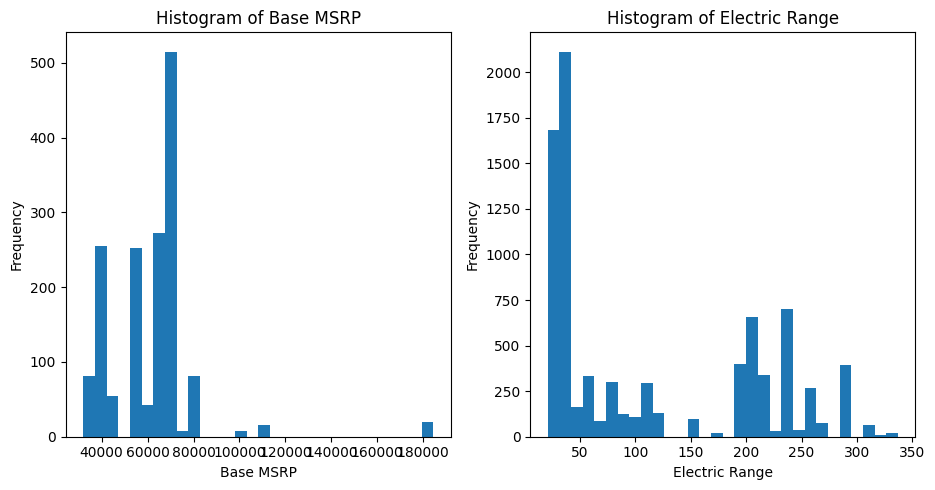

In [ ]:
numeric_cols = ["Base MSRP", "Electric Range"]

plt.figure(figsize=(14, 5))
for i, col_name in enumerate(numeric_cols):
    plt.subplot(1, 3, i + 1)
    plt.hist(ev_pd[col_name].dropna(), bins=30)
    plt.title(f"Histogram of {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The​‍​‌‍​‍‌ plot of Base MSRP reveals that the majority of electric vehicles are priced between $50,000 and $75,000, thus indicating that most of the models are of the average price range. Less than a handful of vehicles is priced over $100,000, implying that the high-end luxury EVs are the least common in the dataset. The distribution is right-skewed, i.e., a few extremely expensive vehicles are pulling the tail towards the higher end.

The Electric Range plot discloses that a lot of the vehicles have quite low ranges (between 20 and 80 miles), which most likely refers to the older or plug-in hybrid models. However, there is also another cluster between 200 and 300 miles, which indicates the presence of modern long-range EVs, thus leading to a multimodal ​‍​‌‍​‍‌distribution.

**3) CORRELATION ANALYSIS FOR NUMERICAL COLUMNS**

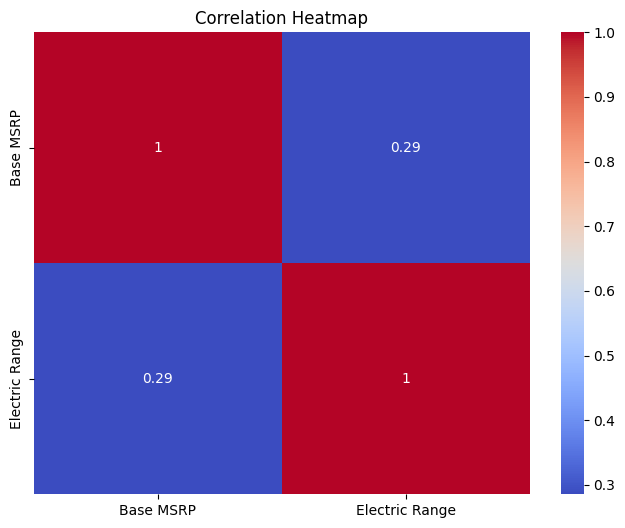

In [ ]:
plt.figure(figsize=(8, 6))
corr_matrix = ev_pd[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

The​‍​‌‍​‍‌ correlation heatmap between variables shows that Base MSRP and Electric Range are two variables that are moderately positively correlated. It means that in most cases, cars with a longer electric range will be more costly. Meanwhile, Model Year has very little correlation with both price and range, so newer or older models do not make much of a difference in these variables. In fact, the data set is telling us that electric range is the only numerical factor that is significantly related to the MSRP, whereas all other relationships are still ​‍​‌‍​‍‌weak.

**4) SCATTERPLOTS FOR KEY RELATIONSHIPS**

**a)Electric Range vs Base MSRP**

Text(0.5, 1.0, 'Electric Range vs Base MSRP')

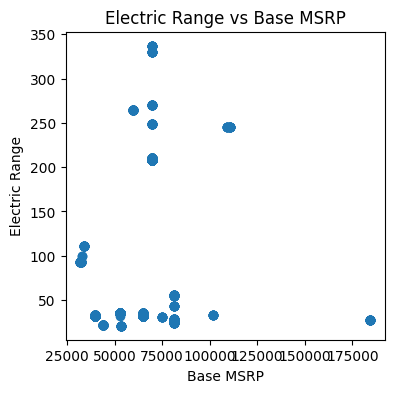

In [ ]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.scatter(ev_pd["Base MSRP"], ev_pd["Electric Range"])
plt.xlabel("Base MSRP")
plt.ylabel("Electric Range")
plt.title("Electric Range vs Base MSRP")

This​‍​‌‍​‍‌ scatterplot is a depiction of the change of Electric Range with Base MSRP of the vehicle. A slight upward trend is visible, which means that vehicles with higher prices are slightly better in terms of electric range. In general, the points are very far apart from each other, which means that the price alone does not significantly determine the range.

**b)Base MSRP vs Model Year**

Text(0.5, 1.0, 'Base MSRP vs Model Year')

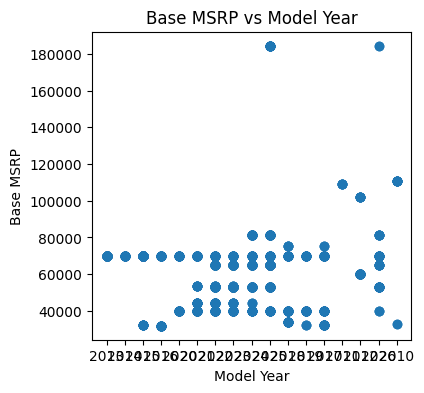

In [ ]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 2)
plt.scatter(ev_pd["Model Year"], ev_pd["Base MSRP"])
plt.xlabel("Model Year")
plt.ylabel("Base MSRP")
plt.title("Base MSRP vs Model Year")

This chart is a comparison of vehicle price (Base MSRP) for different model years. The later model years seem to have a wider range of prices, which is indicative of increased market diversity and more luxurious EV possibilities in recent years. But the spread also indicates that not all new models are expensive, thus there is a variation in different manufacturers.

**c)Electric Range vs Model Year**

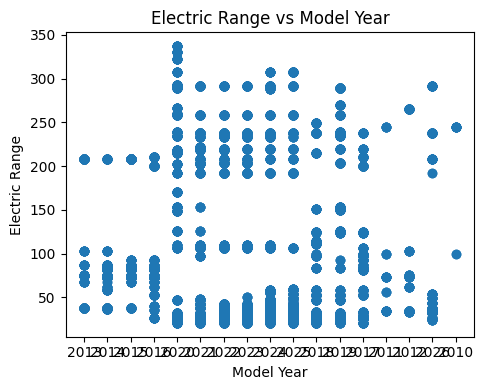

In [ ]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 3)
plt.scatter(ev_pd["Model Year"], ev_pd["Electric Range"])
plt.xlabel("Model Year")
plt.ylabel("Electric Range")
plt.title("Electric Range vs Model Year")
plt.tight_layout()
plt.show()


This scatterplot is about the changes of Electric Range over model years. Slightly upward trend is suggesting that newer vehicles might have better electric range, which is a reflection of the advancements in battery technology. While the improvement is not going to be the same for all models, it is obvious that more recent years have more vehicles with a high ​‍​‌‍​‍‌range.

**5.Count of EVs by Top Manufacturers**

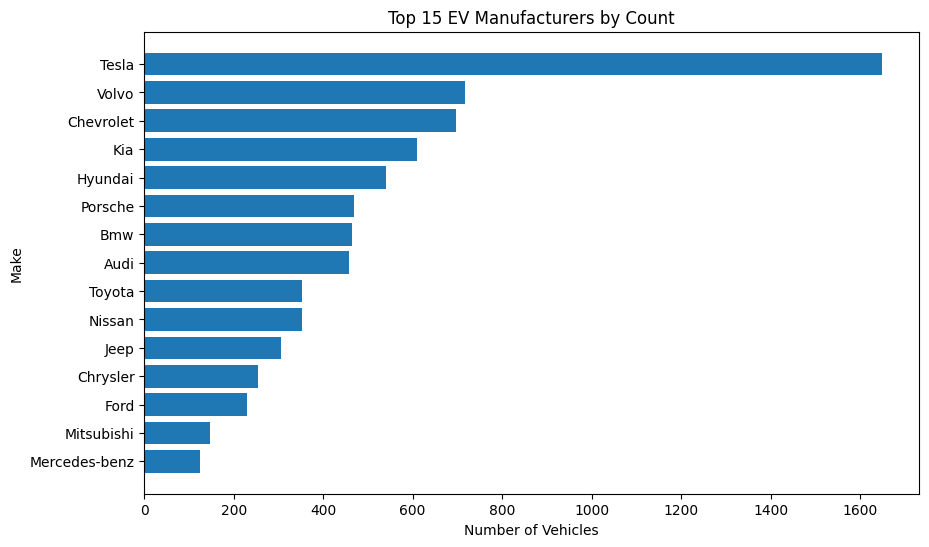

In [ ]:
top_makes = (
    Evnew.groupBy("Make")
         .count()
         .orderBy(col("count").desc())
         .limit(15)
         .toPandas()
)

plt.figure(figsize=(10,6))
plt.barh(top_makes["Make"], top_makes["count"])
plt.gca().invert_yaxis()
plt.title("Top 15 EV Manufacturers by Count")
plt.xlabel("Number of Vehicles")
plt.ylabel("Make")
plt.show()

This​‍​‌‍​‍‌ visualization illustrates the leading EV producers according to the total number of registered vehicles in the dataset. It indicates the brands that dominate the electric vehicle market and those that have a lesser market presence. The distribution allows to recognize the brand diversity and the possible impact of the manufacturer-level trends in EV adoption.

**6.Electric Range by Vehicle Type (BEV vs PHEV)**

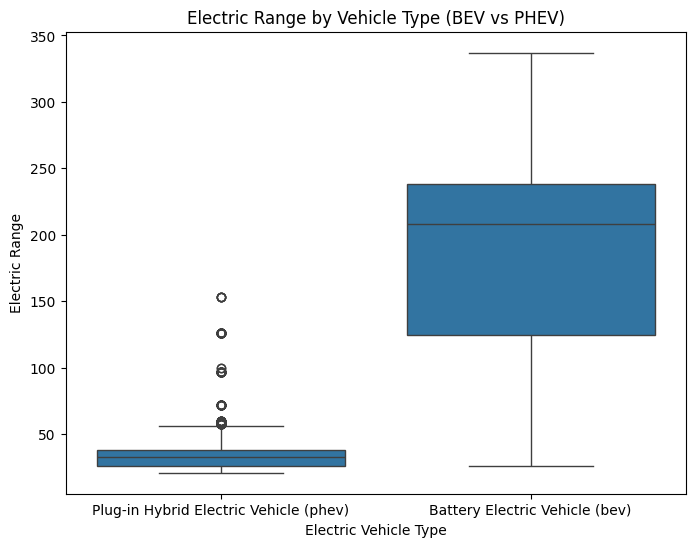

In [ ]:
range_by_type = (
    Evnew.select("Electric Vehicle Type", "Electric Range")
          .toPandas()
)

plt.figure(figsize=(8,6))
sns.boxplot(data=range_by_type, x="Electric Vehicle Type", y="Electric Range")
plt.title("Electric Range by Vehicle Type (BEV vs PHEV)")
plt.xlabel("Electric Vehicle Type")
plt.ylabel("Electric Range")
plt.show()


This visualization contrasts the electric range of BEVs and PHEVs, thus making their performance differences immediately apparent. In general, BEVs show higher range values as they are exclusively powered by electricity, while PHEVs usually have shorter electric-only ranges. Such a statement serves as a justification for why the technological advantages of BEVs are, and also, why the range varies considerably from one vehicle type to ​‍​‌‍​‍‌another.

**7.EV Count Over Years - Bar Chart**

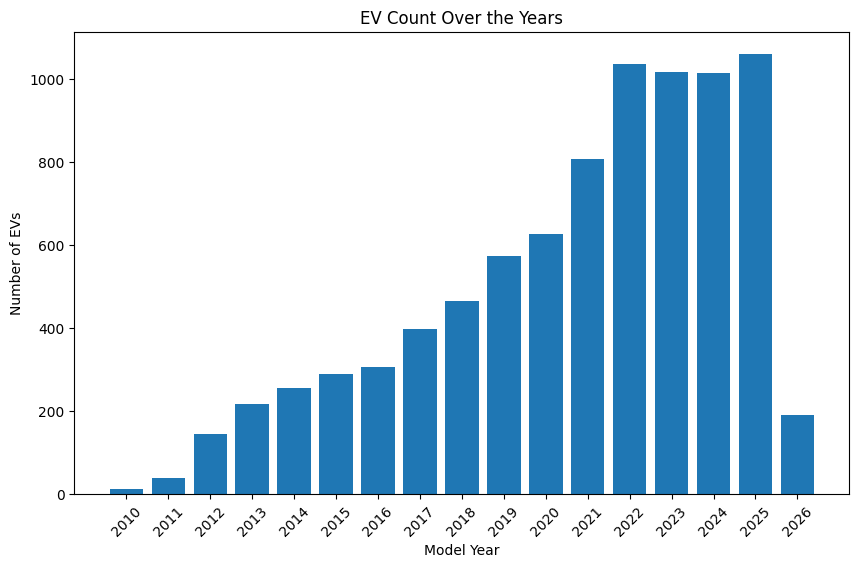

In [ ]:
from pyspark.sql.functions import col, count
import matplotlib.pyplot as plt

# Group EVs by year
ev_years = (
    Evnew.groupBy("Model Year")
         .agg(count("*").alias("EV_Count"))
         .orderBy("Model Year")
         .toPandas()
)

plt.figure(figsize=(10,6))
plt.bar(ev_years["Model Year"], ev_years["EV_Count"])
plt.title("EV Count Over the Years")
plt.xlabel("Model Year")
plt.ylabel("Number of EVs")
plt.xticks(rotation=45)
plt.show()


The​‍​‌‍​‍‌ bar chart depicts the change in the number of electric vehicles for various model years and thus helps to understand growth patterns over time. The number of EVs for newer model years is significantly higher, which is a clear indication of the increasing adoption and production of electric vehicles over the last few years. The upward movement of the curve indicates that the popularity of EV has been accelerated, and thus more registrations have taken place.

**8.Pie Chart – CAFV Eligibility & Electric Vehicle Type**

A) CAFV Eligibility Pie Chart

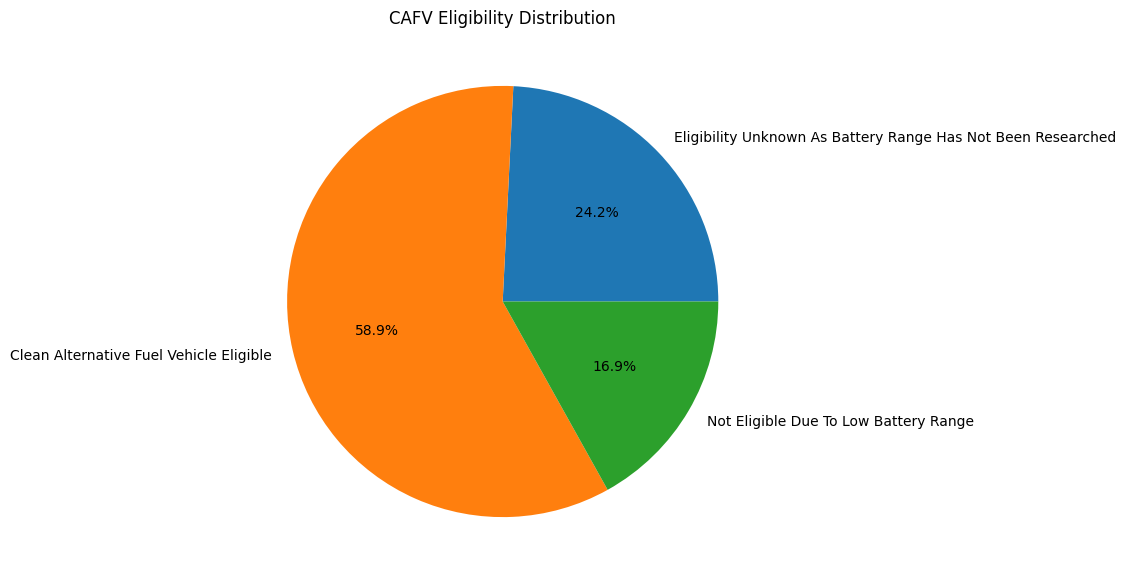

In [ ]:
cafv_pd = (
    Evnew.groupBy("Clean Alternative Fuel Vehicle (CAFV) Eligibility")
         .count()
         .toPandas()
)

plt.figure(figsize=(7,7))
plt.pie(
    cafv_pd["count"],
    labels=cafv_pd["Clean Alternative Fuel Vehicle (CAFV) Eligibility"],
    autopct="%1.1f%%"
)
plt.title("CAFV Eligibility Distribution")
plt.show()


**B) Electric Vehicle Type Pie Chart**

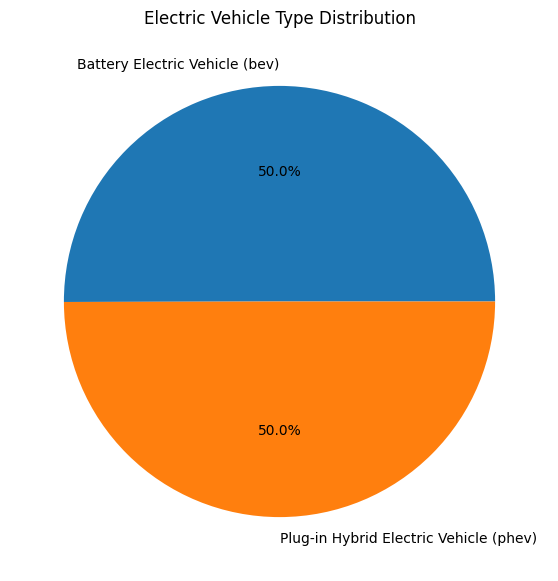

In [ ]:
evtype_pd = (
    Evnew.groupBy("Electric Vehicle Type")
         .count()
         .toPandas()
)

plt.figure(figsize=(7,7))
plt.pie(
    evtype_pd["count"],
    labels=evtype_pd["Electric Vehicle Type"],
    autopct="%1.1f%%"
)
plt.title("Electric Vehicle Type Distribution")
plt.show()


The different categories are represented to the greatest extent by the pie chart, thus one can very easily determine the group which has the highest share among the electric vehicles. Also, it points to the dominant category, e.g., whether most vehicles are BEVs or if the majority qualify for CAFV eligibility. The chart, in general, provides a quick visual comparison of the proportions and facilitates the disclosure of the imbalances or trends in the data set.

**9.Correlation Including Categorical Variables**

Categorical correlation = Cramér's V

Cramér's V for categorical variables

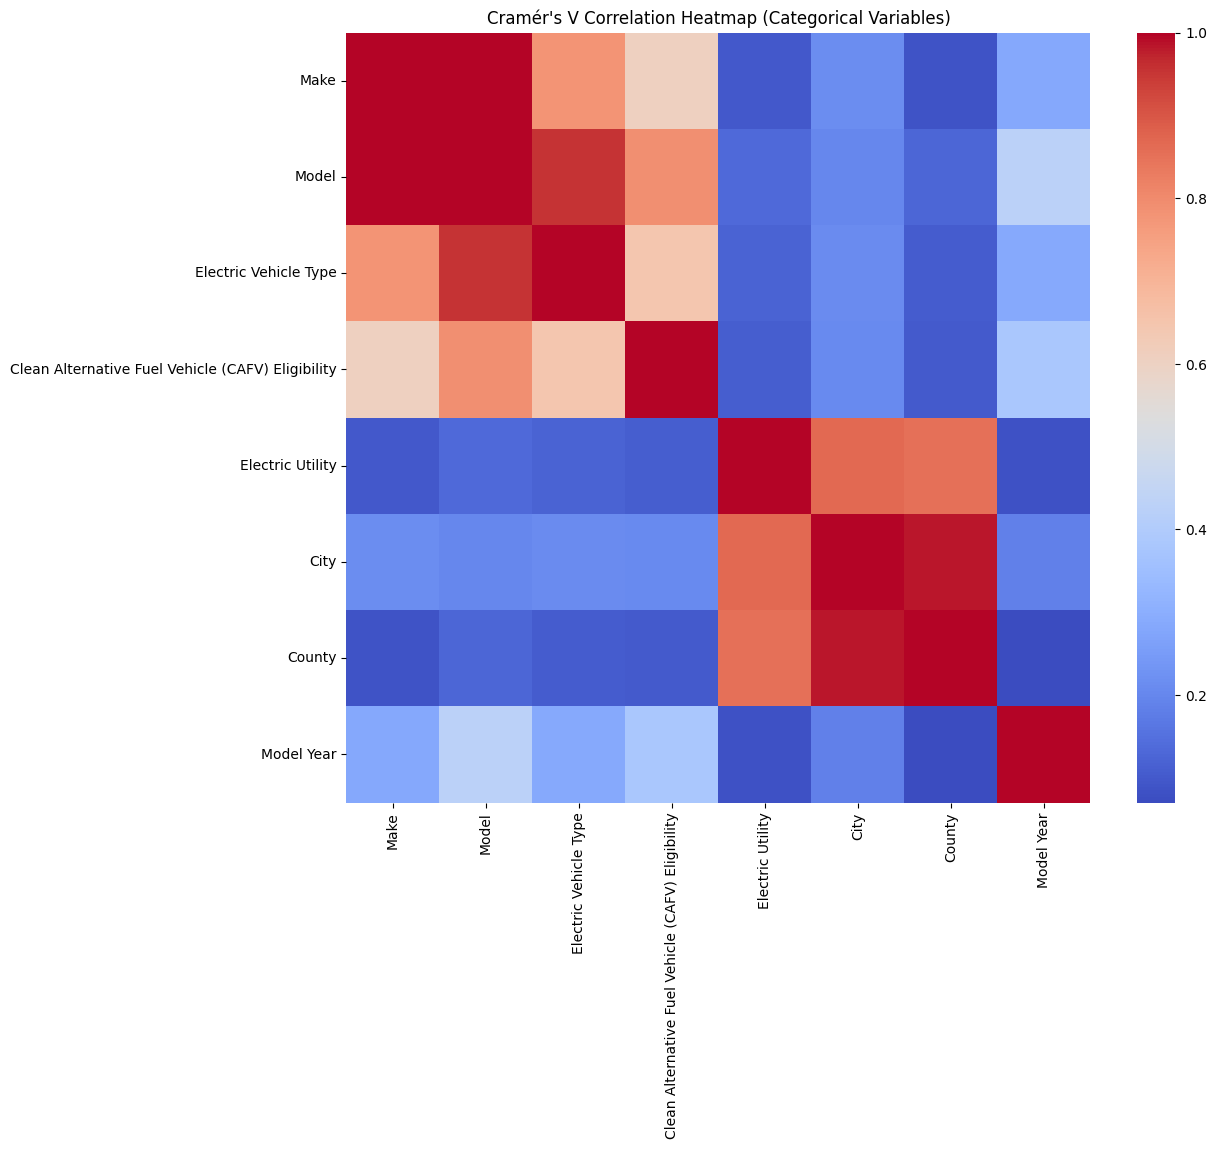

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency


# FIX: restore Python's min()
import builtins
min = builtins.min


def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))


cat_cols = [
    "Make",
    "Model",
    "Electric Vehicle Type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    "Electric Utility",
    "City",
    "County",
    "Model Year"
]

ev_cat_pd = Evnew.select(cat_cols).toPandas()

cramer_matrix = pd.DataFrame(
    np.zeros((len(cat_cols), len(cat_cols))),
    columns=cat_cols, index=cat_cols
)

for col1 in cat_cols:
    for col2 in cat_cols:
        confusion = pd.crosstab(ev_cat_pd[col1], ev_cat_pd[col2])
        cramer_matrix.loc[col1, col2] = cramers_v(confusion)

plt.figure(figsize=(12,10))
sns.heatmap(cramer_matrix, annot=False, cmap="coolwarm")
plt.title("Cramér's V Correlation Heatmap (Categorical Variables)")
plt.show()



The categorical correlation heatmap represents the intensity of the relations between different categorical variables by the color used. The darkest colors stand for the strongest associations, whereas the lightest ones signify weak or no relationships between categories. The chart is useful in discovering the factors that, e.g., Make, Model, or Vehicle Type, are that change together thus resulting in better understanding and feature selection for the ​‍​‌‍​‍‌model.

**Modelling**

**Regression Model - Random Forest Regressor**

In [ ]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

#  DATA SELECTION
reg_df = Evnew.select(
    "Make", "Model", "Model Year", "Electric Vehicle Type",
    "Electric Range"
).dropna()

# Convert target to numeric
reg_df = reg_df.withColumn("Electric Range", col("Electric Range").cast("double"))


#  FEATURE ENCODING
make_indexer  = StringIndexer(inputCol="Make", outputCol="Make_Idx", handleInvalid="keep")
model_indexer = StringIndexer(inputCol="Model", outputCol="Model_Idx", handleInvalid="keep")
type_indexer  = StringIndexer(inputCol="Electric Vehicle Type", outputCol="Type_Idx", handleInvalid="keep")
year_indexer = StringIndexer(inputCol="Model Year", outputCol="ModelYear_Idx", handleInvalid="keep")

assembler = VectorAssembler(
    inputCols=["Make_Idx", "Model_Idx", "Type_Idx", "ModelYear_Idx"],
    outputCol="features"
)


#  MODEL SELECTION
rf_reg = RandomForestRegressor(
    labelCol="Electric Range",
    featuresCol="features",
    maxDepth=8,
    numTrees=60,
    maxBins=128
)

pipeline = Pipeline(stages=[
    make_indexer, model_indexer, type_indexer, year_indexer, assembler, rf_reg
])


# TRAIN/TEST SPLIT
train, test = reg_df.randomSplit([0.7, 0.3], seed=42)

model = pipeline.fit(train)
preds = model.transform(test)

#  EVALUATION
rmse_evaluator = RegressionEvaluator(
    labelCol="Electric Range",
    predictionCol="prediction",
    metricName="rmse"
)

r2_evaluator = RegressionEvaluator(
    labelCol="Electric Range",
    predictionCol="prediction",
    metricName="r2"
)

mse_evaluator = RegressionEvaluator(
    labelCol="Electric Range",
    predictionCol="prediction",
    metricName="mse"
)

rmse = rmse_evaluator.evaluate(preds)
r2 = r2_evaluator.evaluate(preds)
mse = mse_evaluator.evaluate(preds)

print("Regression RMSE:", rmse)
print("Regression R2 :", r2)
print("Regression MSE:", mse)

Regression RMSE: 8.077126265781729
Regression R2 : 0.9926638654311837
Regression MSE: 65.2399687133811


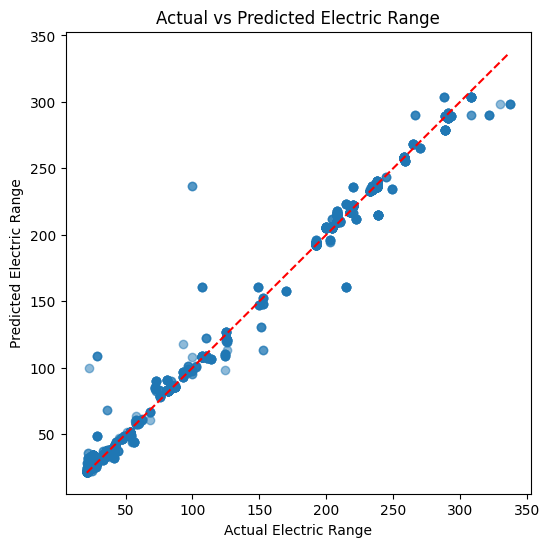

In [ ]:

# Collect actual vs predicted
preds_pd = preds.select("Electric Range", "prediction").toPandas()

plt.figure(figsize=(6,6))
plt.scatter(preds_pd["Electric Range"], preds_pd["prediction"], alpha=0.5)
plt.plot([preds_pd["Electric Range"].min(), preds_pd["Electric Range"].max()],
         [preds_pd["Electric Range"].min(), preds_pd["Electric Range"].max()],
         color="red", linestyle="--")
plt.xlabel("Actual Electric Range")
plt.ylabel("Predicted Electric Range")
plt.title("Actual vs Predicted Electric Range")
plt.show()


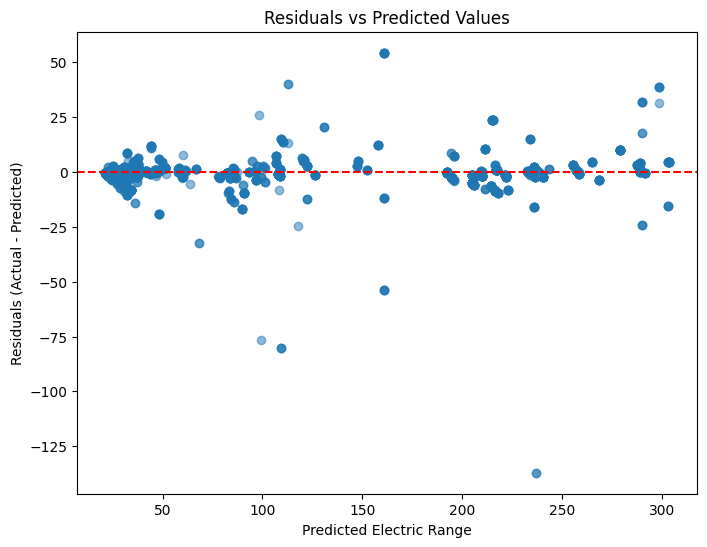

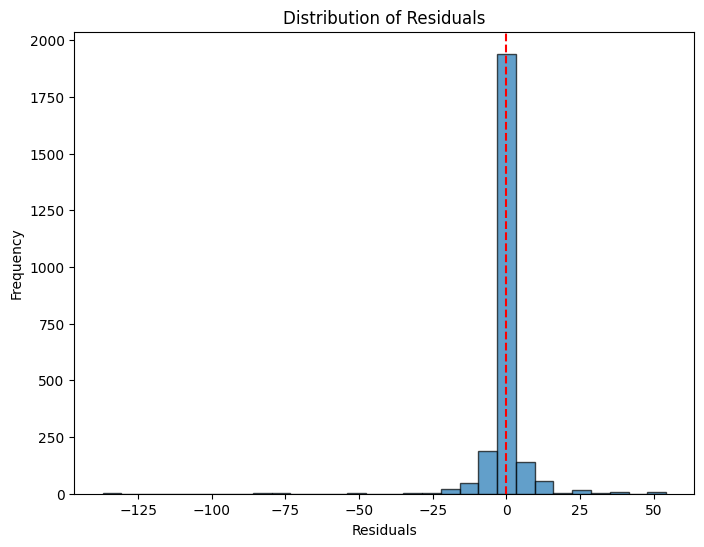

In [ ]:
# Calculate residuals
preds_pd["residuals"] = preds_pd["Electric Range"] - preds_pd["prediction"]

# Scatter plot: residuals vs predicted
plt.figure(figsize=(8,6))
plt.scatter(preds_pd["prediction"], preds_pd["residuals"], alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Electric Range")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.show()

# Histogram of residuals
plt.figure(figsize=(8,6))
plt.hist(preds_pd["residuals"], bins=30, edgecolor="black", alpha=0.7)
plt.axvline(x=0, color="red", linestyle="--")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()


In [ ]:
# Get the trained RandomForestRegressor stage from the pipeline
rf_model = model.stages[-1]

# Extract feature importances
importances = rf_model.featureImportances

# Map back to feature names
feature_names = ["Make_Idx", "Model_Idx", "Type_Idx", "ModelYear_Idx"]
importance_dict = dict(zip(feature_names, importances))

print("Feature Importances:")
for f, imp in importance_dict.items():
    print(f"{f}: {imp:.4f}")


Feature Importances:
Make_Idx: 0.1398
Model_Idx: 0.6219
Type_Idx: 0.2048
ModelYear_Idx: 0.0334


**Gradient** **Boosting** -** Electric Range Prediction**

In [ ]:
from pyspark.sql.functions import col
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import GBTRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

#  DATA SELECTION
reg_df = Evnew.select(
    "Make", "Model", "Electric Vehicle Type",
    "Electric Range"
).dropna()

# Convert target to numeric
reg_df = reg_df.withColumn("Electric Range", col("Electric Range").cast("double"))

# FEATURE ENCODING
make_indexer  = StringIndexer(inputCol="Make", outputCol="Make_Idx", handleInvalid="keep")
model_indexer = StringIndexer(inputCol="Model", outputCol="Model_Idx", handleInvalid="keep")
type_indexer  = StringIndexer(inputCol="Electric Vehicle Type", outputCol="Type_Idx", handleInvalid="keep")

assembler = VectorAssembler(
    inputCols=["Make_Idx", "Model_Idx", "Type_Idx"],
    outputCol="features"
)

#  MODEL SELECTION
gbt_reg = GBTRegressor(
    labelCol="Electric Range",
    featuresCol="features",
    maxIter=50,   # number of boosting iterations
    maxDepth=5,    # max depth per tree
    stepSize=0.1,  # learning rate
    seed=42,
    maxBins=128
)

# PIPELINE
pipeline = Pipeline(stages=[make_indexer, model_indexer, type_indexer, assembler, gbt_reg])

# TRAIN/TEST SPLIT
train, test = reg_df.randomSplit([0.7, 0.3], seed=42)

# MODEL TRAINING
model = pipeline.fit(train)
# PREDICTION
preds = model.transform(test)

# EVALUATION
rmse_evaluator = RegressionEvaluator(
    labelCol="Electric Range",
    predictionCol="prediction",
    metricName="rmse"
)
r2_evaluator = RegressionEvaluator(
    labelCol="Electric Range",
    predictionCol="prediction",
    metricName="r2"
)
mse_evaluator = RegressionEvaluator(
    labelCol="Electric Range",
    predictionCol="prediction",
    metricName="mse"
)

rmse = rmse_evaluator.evaluate(preds)
r2   = r2_evaluator.evaluate(preds)
mse  = mse_evaluator.evaluate(preds)

print("GBT Regression RMSE:", rmse)
print("GBT Regression R² :", r2)
print("GBT Regression MSE:", mse)

preds.select("Make", "Model", "Electric Vehicle Type", "Electric Range", "prediction").show(10)


GBT Regression RMSE: 22.326119575212097
GBT Regression R² : 0.9442243147052923
GBT Regression MSE: 498.45561528666883
+----------+------+---------------------+--------------+-----------------+
|      Make| Model|Electric Vehicle Type|Electric Range|       prediction|
+----------+------+---------------------+--------------+-----------------+
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|32.99998118524697|
|Alfa Romeo|Tonale| Plug-in Hybrid El...|          33.0|3

In [ ]:
# Get the trained GBTRegressor stage from the pipeline
gb_model = model.stages[-1]

# Extract feature importances
importances = gb_model.featureImportances

# Map back to feature names
feature_names = ["Make_Idx", "Model_Idx", "Type_Idx"]
importance_dict = dict(zip(feature_names, importances))

print("Feature Importances:")
for f, imp in importance_dict.items():
    print(f"{f}: {imp:.4f}")


Feature Importances:
Make_Idx: 0.0068
Model_Idx: 0.9837
Type_Idx: 0.0094


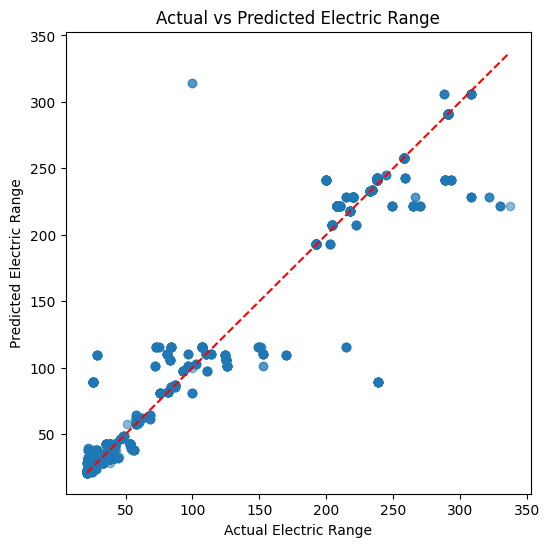

In [ ]:
# Collect actual vs predicted
preds_pd = preds.select("Electric Range", "prediction").toPandas()

plt.figure(figsize=(6,6))
plt.scatter(preds_pd["Electric Range"], preds_pd["prediction"], alpha=0.5)
plt.plot([preds_pd["Electric Range"].min(), preds_pd["Electric Range"].max()],
         [preds_pd["Electric Range"].min(), preds_pd["Electric Range"].max()],
         color="red", linestyle="--")
plt.xlabel("Actual Electric Range")
plt.ylabel("Predicted Electric Range")
plt.title("Actual vs Predicted Electric Range")
plt.show()

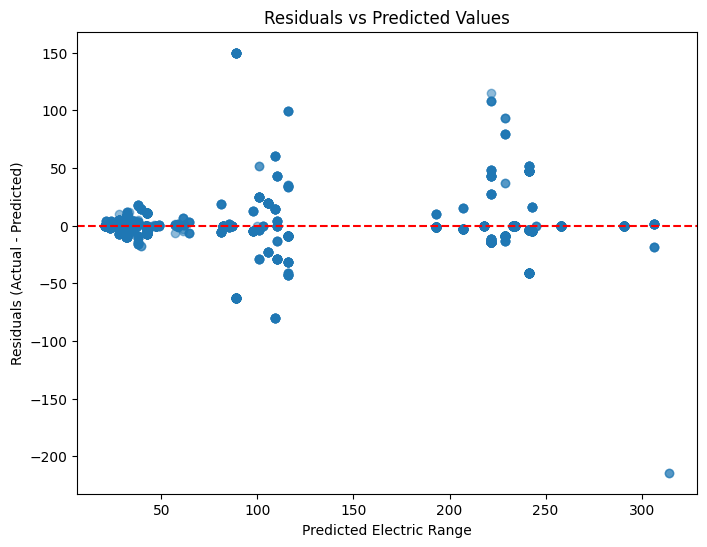

In [ ]:
# Calculate residuals
preds_pd["residuals"] = preds_pd["Electric Range"] - preds_pd["prediction"]

# Scatter plot: residuals vs predicted
plt.figure(figsize=(8,6))
plt.scatter(preds_pd["prediction"], preds_pd["residuals"], alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Electric Range")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted Values")
plt.show()

Classification Model (Predict CAFV Eligibility)

Random Forest Classifier

In [ ]:
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

#  DATA SELECTION
cls_df = Evnew.select(
    "Make", "Model", "Model Year", "Electric Vehicle Type",
    "Electric Range",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility"
).dropna()

# Convert target to category index
label_indexer = StringIndexer(
    inputCol="Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    outputCol="label"
)

# Encode input categorical features
make_indexer  = StringIndexer(inputCol="Make", outputCol="Make_Idx", handleInvalid="keep")
model_indexer = StringIndexer(inputCol="Model", outputCol="Model_Idx", handleInvalid="keep")
type_indexer  = StringIndexer(inputCol="Electric Vehicle Type", outputCol="Type_Idx", handleInvalid="keep")
year_indexer = StringIndexer(inputCol="Model Year", outputCol="ModelYear_Idx", handleInvalid="keep")

assembler = VectorAssembler(
    inputCols=["Make_Idx", "Model_Idx", "Type_Idx", "ModelYear_Idx", "Electric Range"],
    outputCol="features"
)

# MODEL
rf_cls = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=80,
    maxDepth=10,
    maxBins=128
)

pipeline = Pipeline(stages=[
    label_indexer, make_indexer, model_indexer, type_indexer,year_indexer, assembler, rf_cls
])

# TRAIN/TEST SPLIT
train, test = cls_df.randomSplit([0.7, 0.3], seed=42)

model = pipeline.fit(train)
preds = model.transform(test)

# EVALUATION
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)
precision_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)
recall_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

accuracy = acc_eval.evaluate(preds)
print("Classification Accuracy:", accuracy)
precision = precision_eval.evaluate(preds)
print("Classification Precision:", precision)
recall = recall_eval.evaluate(preds)
print("Classification Recall:", recall)
f1 = f1_eval.evaluate(preds)
print("Classification F1 Score:", f1)


Classification Accuracy: 0.9959100204498977
Classification Precision: 0.9959091323722002
Classification Recall: 0.9959100204498977
Classification F1 Score: 0.995905559696538


In [ ]:
# Get the trained RFClassifier stage from the pipeline
rfc_model = model.stages[-1]

# Extract feature importances
importances = rfc_model.featureImportances

# Map back to feature names
feature_names = ["Make_Idx", "Model_Idx", "Type_Idx","ModelYear_Idx","Electric Range"]
importance_dict = dict(zip(feature_names, importances))

print("Feature Importances:")
for f, imp in importance_dict.items():
    print(f"{f}: {imp:.4f}")

Feature Importances:
Make_Idx: 0.0505
Model_Idx: 0.1458
Type_Idx: 0.0845
ModelYear_Idx: 0.2804
Electric Range: 0.4387


In [ ]:
# Extract the label indexer stage (first stage of your pipeline)
label_indexer_model = model.stages[0]

# Get the ordering of labels
class_labels = label_indexer_model.labels
print("Class Labels:", class_labels)


Class Labels: ['Clean Alternative Fuel Vehicle Eligible', 'Eligibility Unknown As Battery Range Has Not Been Researched', 'Not Eligible Due To Low Battery Range']


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Confusion Matrix:
 [[1447.    3.    0.]
 [   7.  557.    0.]
 [   0.    0.  431.]]


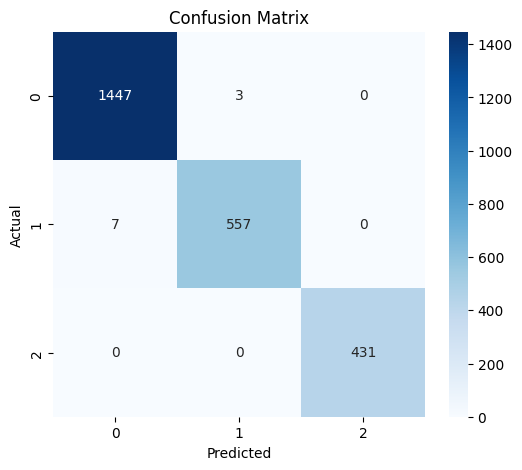

In [ ]:
import seaborn as sns
from pyspark.mllib.evaluation import MulticlassMetrics

# Select prediction and label
preds_and_labels = preds.select("prediction", "label") \
    .rdd.map(lambda x: (float(x[0]), float(x[1])))

# Compute confusion matrix
metrics = MulticlassMetrics(preds_and_labels)
cm = metrics.confusionMatrix().toArray()

# Print confusion matrix
print("Confusion Matrix:\n", cm)
# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


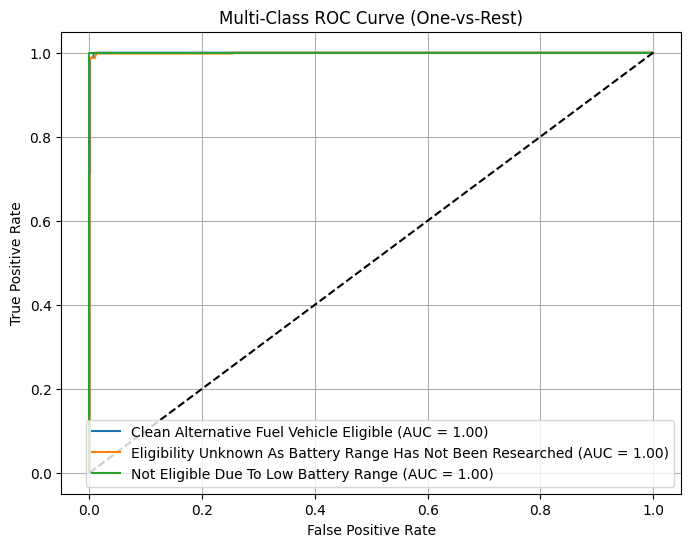

In [ ]:
from sklearn.metrics import roc_curve, auc

pdf = preds.select("label", "probability").toPandas()
# Convert probability vector column to array
pdf["prob_array"] = pdf["probability"].apply(lambda x: np.array(x))

plt.figure(figsize=(8,6))

for i, class_name in enumerate(class_labels):

    # True labels: 1 if this class, 0 otherwise
    y_true = (pdf["label"] == i).astype(int)

    # Probability of belonging to class i
    y_score = pdf["prob_array"].apply(lambda x: x[i])

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")


plt.plot([0,1], [0,1], "k--")   # diagonal

plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.grid(True)
plt.show()





Logistic Regression - Predict CAFV Eligibility

In [ ]:
from pyspark.ml.classification import LogisticRegression

#  LOGISTIC REGRESSION MODEL
lr_cls = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0
)

#  PIPELINE
pipeline_lr = Pipeline(stages=[
    label_indexer, make_indexer, model_indexer, type_indexer, year_indexer, assembler, lr_cls
])

#  TRAIN MODEL
lr_model = pipeline_lr.fit(train)

#  PREDICTION
lr_preds = lr_model.transform(test)

#  EVALUATION METRICS
metrics = ["accuracy", "f1", "weightedPrecision", "weightedRecall"]
results = {}

for metric in metrics:
    evaluator = MulticlassClassificationEvaluator(
        labelCol="label",
        predictionCol="prediction",
        metricName=metric
    )
    results[metric] = evaluator.evaluate(lr_preds)

print("Logistic Regression Metrics:")
for metric, value in results.items():
    print(f"{metric}: {value:.4f}")


Logistic Regression Metrics:
accuracy: 0.7538
f1: 0.6920
weightedPrecision: 0.7331
weightedRecall: 0.7538


In [ ]:
# Get the trained RFClassifier stage from the pipeline
lor_model = model.stages[-1]

# Extract feature importances
importances = lor_model.featureImportances

# Map back to feature names
feature_names = ["Make_Idx", "Model_Idx", "Type_Idx","ModelYear_Idx","Electric Range"]
importance_dict = dict(zip(feature_names, importances))

print("Feature Importances:")
for f, imp in importance_dict.items():
    print(f"{f}: {imp:.4f}")

Feature Importances:
Make_Idx: 0.0505
Model_Idx: 0.1458
Type_Idx: 0.0845
ModelYear_Idx: 0.2804
Electric Range: 0.4387


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


Confusion Matrix:
 [[1363.   76.   11.]
 [ 100.  464.    0.]
 [ 415.    0.   16.]]


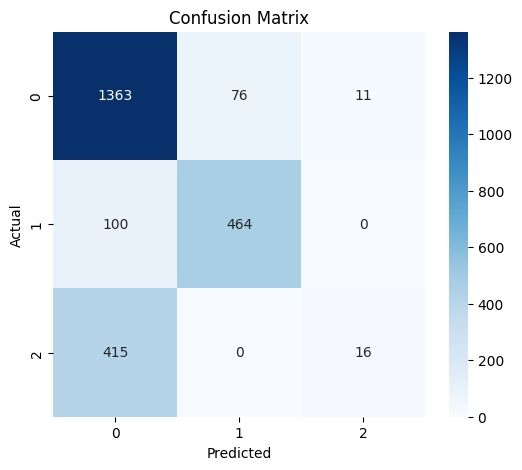

In [ ]:
# Select prediction and label
preds_and_labels = lr_preds.select("prediction", "label") \
    .rdd.map(lambda x: (float(x[0]), float(x[1])))

# Compute confusion matrix
metrics = MulticlassMetrics(preds_and_labels)
cm = metrics.confusionMatrix().toArray()

# Print confusion matrix
print("Confusion Matrix:\n", cm)
# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

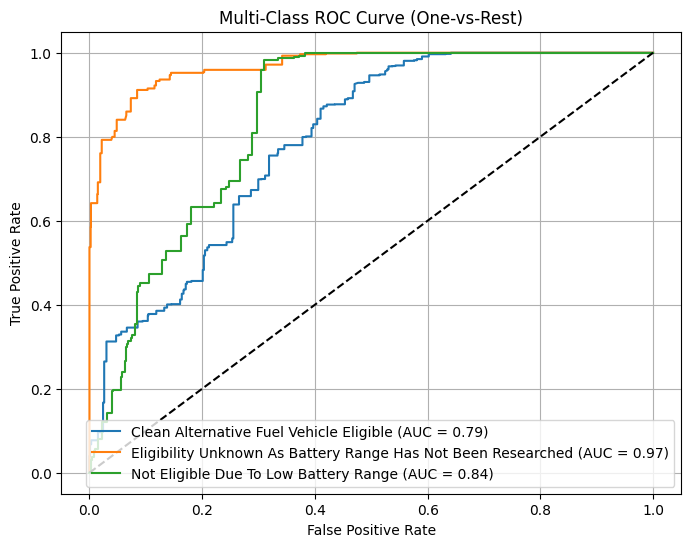

In [ ]:
# Extract the label indexer stage (first stage of your pipeline)
label_indexer_model = model.stages[0]

# Get the ordering of labels
class_labels = label_indexer_model.labels

pdf = lr_preds.select("label", "probability").toPandas()
# Convert probability vector column to array
pdf["prob_array"] = pdf["probability"].apply(lambda x: np.array(x))

plt.figure(figsize=(8,6))

for i, class_name in enumerate(class_labels):

    # True labels: 1 if this class, 0 otherwise
    y_true = (pdf["label"] == i).astype(int)

    # Probability of belonging to class i
    y_score = pdf["prob_array"].apply(lambda x: x[i])

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")


plt.plot([0,1], [0,1], "k--")   # diagonal

plt.title("Multi-Class ROC Curve (One-vs-Rest)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")

plt.grid(True)
plt.show()

